In [29]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv("/content/sample_data/california_housing_test.csv")

In [3]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.05,37.37,27.0,3885.0,661.0,1537.0,606.0,6.6085,344700.0
1,-118.30,34.26,43.0,1510.0,310.0,809.0,277.0,3.5990,176500.0
2,-117.81,33.78,27.0,3589.0,507.0,1484.0,495.0,5.7934,270500.0
3,-118.36,33.82,28.0,67.0,15.0,49.0,11.0,6.1359,330000.0
4,-119.67,36.33,19.0,1241.0,244.0,850.0,237.0,2.9375,81700.0


In [4]:
import seaborn as sns
import matplotlib.pyplot as plt


<Axes: >

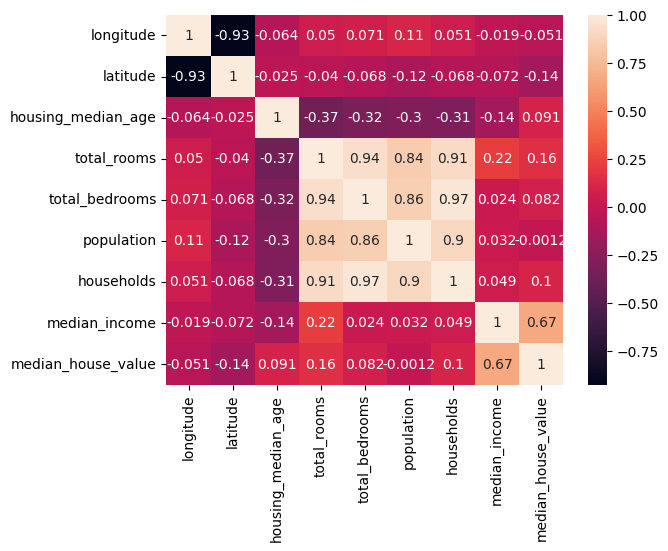

In [5]:
sns.heatmap(df.corr(),annot=True)

In [7]:
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [9]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [11]:
pred = rf.predict(X_test)

In [15]:
mse = mean_squared_error(y_test, pred)
r2 = r2_score(y_test, pred)
print("Mean Squared Error:", mse)
print("R-squared:", r2)

Mean Squared Error: 3315046418.020424
R-squared: 0.7367657879959226


In [16]:
gs = GridSearchCV(estimator=rf, param_grid={'n_estimators': range(10, 101, 10)}, cv=5, scoring='neg_mean_squared_error')
gs.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
             param_grid={'n_estimators': range(10, 101, 10)},
             scoring='neg_mean_squared_error')

In [20]:
pred = gs.predict(X_test)

In [21]:
mse = mean_squared_error(y_test, pred)
r2 = r2_score(y_test, pred)
print("Mean Squared Error:", mse)
print("R-squared:", r2)

Mean Squared Error: 3340015823.480308
R-squared: 0.7347830701266604


In [23]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression

In [24]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [25]:
pred = lr.predict(X_test)

In [26]:
mse = mean_squared_error(y_test, pred)
r2 = r2_score(y_test, pred)
print("Mean Squared Error:", mse)
print("R-squared:", r2)

Mean Squared Error: 4586505886.68125
R-squared: 0.6358044169850408


In [30]:
kr = KNeighborsRegressor(n_neighbors=5, weights='uniform', algorithm='auto', leaf_size=30, p=2, metric='minkowski', metric_params=None, n_jobs=None)

In [36]:
st = StackingRegressor(estimators=[('rf', rf), ('lr', lr),('kr',kr)],final_estimator=KNeighborsRegressor(n_neighbors=40),n_jobs=None,cv=5)
st.fit(X_train, y_train)

StackingRegressor(cv=5,
                  estimators=[('rf', RandomForestRegressor(random_state=42)),
                              ('lr', LinearRegression()),
                              ('kr', KNeighborsRegressor())],
                  final_estimator=KNeighborsRegressor(n_neighbors=40))

In [37]:
pred = st.predict(X_test)
mse = mean_squared_error(y_test, pred)
r2 = r2_score(y_test, pred)
print("Mean Squared Error:", mse)
print("R-squared:", r2)

Mean Squared Error: 3214155672.2022634
R-squared: 0.7447771074844161


In [35]:
df['median_house_value'].value_counts()

,count
median_house_value,
500001.0,125
137500.0,23
162500.0,21
225000.0,17
350000.0,14
...,...
376200.0,1
89100.0,1
166900.0,1
